# CardioFusion: modelo prognóstico

A Entrega 2 mostrou quais biomarcadores acrescentam informação sobre a avaliação de beira-leito. Este notebook junta os que sobreviveram num **modelo único** e responde a três perguntas que o quadro de candidatos não responde.

O modelo ordena bem os pacientes por risco? As probabilidades que ele produz significam alguma coisa? E ele mudaria alguma decisão?

## O que este modelo prediz

> Dada a informação disponível **nas primeiras horas de internação em UTI**, qual a probabilidade de que esta internação termine em **óbito hospitalar**?

A saída é um número entre 0 e 1. Um paciente com 0,32 não é um paciente que vai morrer: é um paciente cujo perfil se parece com o de um grupo em que aproximadamente um terço morreu.

| | |
|---|---|
| **Entrada** | Seis medidas da primeira janela: idade, Glasgow, RDW, ânion gap, ureia e pressão sistólica |
| **Saída** | Probabilidade de óbito hospitalar, de 0 a 1 |
| **Momento** | Após a primeira coleta laboratorial, mediana de 2,7 horas depois da entrada na UTI |
| **Unidade** | A internação, não o paciente |
| **Horizonte** | Todo o período de hospitalização, sem data fixa |

## O que este modelo não faz

**Não diagnostica.** A insuficiência cardíaca já está estabelecida em todos os pacientes da coorte, por critério de seleção. O modelo não decide quem tem a doença.

**Não indica tratamento.** Ele estima risco, e risco alto não implica conduta específica. A ponte entre "este paciente tem 30% de probabilidade" e "faça X" não é feita por nenhum número deste notebook.

**Não estabelece causa.** Um ânion gap alto prediz óbito; baixá-lo artificialmente não salvaria ninguém. O modelo lê marcadores de gravidade, não alavancas de intervenção.

**Não substitui julgamento.** Ele foi construído justamente para medir o que **acrescenta** à avaliação clínica, e essa formulação pressupõe que a avaliação clínica continua existindo.

> **Estado deste notebook.** Ele ainda **não foi executado**. O código está escrito e a estrutura definida, mas nenhum resultado abaixo foi produzido. As afirmações numéricas que aparecem no texto vêm da Entrega 2 e estão marcadas como tal.

## 1 A tarefa de predição

### 1.1 Por que probabilidade, e não classificação

Seria possível fazer o modelo responder "sim" ou "não". Seria pior.

Uma classificação obriga a escolher um limiar antes de saber como o resultado será usado, e o limiar certo depende do custo de errar em cada direção. Deixar de vigiar quem vai deteriorar custa muito mais que vigiar de perto alguém que ficaria bem, mas quanto mais depende da unidade, da ocupação de leitos e da equipe disponível.

Entregando a probabilidade, essa escolha fica com quem tem contexto para fazê-la. Um serviço com folga pode intensificar vigilância acima de 20%; outro, saturado, pode precisar operar em 40%. O mesmo modelo serve aos dois.

### 1.2 O que o modelo enxerga, e quando

O modelo é deliberadamente cego a tudo que acontece depois da primeira janela. Ele não vê a evolução, não vê o tratamento administrado e não vê o tempo de permanência. Essa cegueira é uma escolha de desenho, não uma limitação de dados: previsão feita com informação posterior ao momento da decisão não é previsão.

Duas variáveis existem no corte e ficam **explicitamente fora** por vazamento. O tempo de permanência só é conhecido na alta. O local de destino contém a categoria de óbito, e usá-lo seria pedir ao modelo que copiasse a resposta.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.calibration import calibration_curve
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

DATA = Path("../data/cohort/cases")
OUTCOME = "obito_hospitalar"
SEED = 42

# as seis variáveis do modelo, fixadas pela evidência da Entrega 2
PREDITORES = ["idade", "gcs_admissao", "RDW", "Anion Gap", "log_urea", "Systolic BP"]

## 2 Construção da matriz

O notebook é autossuficiente, como os anteriores: lê as pastas por internação e monta apenas o necessário para os seis preditores. Nada é importado de `src/`.

In [2]:
clinical_rows, lab_rows, vitals_rows, gcs_rows = [], [], [], []
for folder in sorted(p for p in DATA.iterdir() if p.is_dir()):
    record = json.loads((folder / "clinical_data.json").read_text())
    pid = record["paciente_id"]
    clinical_rows.append(
        {
            "paciente_id": pid,
            "idade": record["demografia"]["idade"],
            OUTCOME: bool(record["admissao"]["obito_hospitalar"]),
        }
    )
    for name, target in [
        ("laboratory.csv", lab_rows),
        ("vitals_series.csv", vitals_rows),
        ("gcs_series.csv", gcs_rows),
    ]:
        path = folder / name
        if path.exists():
            df = pd.read_csv(path)
            df.insert(0, "paciente_id", pid)
            target.append(df)

cohort = pd.DataFrame(clinical_rows).set_index("paciente_id")
labs = pd.concat(lab_rows, ignore_index=True)
vitals = pd.concat(vitals_rows, ignore_index=True)
gcs = pd.concat(gcs_rows, ignore_index=True)

X = cohort.join(
    labs.pivot(index="paciente_id", columns="exame", values="valor")[
        ["RDW", "Anion Gap", "Urea Nitrogen"]
    ]
)
X["Systolic BP"] = (
    vitals[vitals.sinal == "Systolic BP"]
    .sort_values("horas_da_janela")
    .groupby("paciente_id")
    .valor.first()
)
X["gcs_admissao"] = gcs.sort_values("horas_da_janela").groupby("paciente_id")["GCS total"].first()

# escala logarítmica: a Entrega 2 mostrou que a ureia rende +0,054 assim, contra +0,035 na escala bruta
X["log_urea"] = np.log1p(X["Urea Nitrogen"].clip(lower=0))

modelo_dados = X[PREDITORES + [OUTCOME]].dropna()
print(
    f"internações com os seis preditores completos: {len(modelo_dados)} "
    f"({len(modelo_dados) / len(X):.1%} da coorte)"
)
print(f"óbitos: {int(modelo_dados[OUTCOME].sum())} " f"({modelo_dados[OUTCOME].mean():.1%})")
print(f"eventos por variável: {modelo_dados[OUTCOME].sum() / len(PREDITORES):.1f}")

internações com os seis preditores completos: 958 (95.8% da coorte)
óbitos: 151 (15.8%)
eventos por variável: 25.2


## 3 Especificação do modelo

### 3.1 As seis variáveis, e por que essas

| Variável | Papel | Evidência da Entrega 2 |
|---|---|---|
| `idade` | ajuste | Confundidor principal, declarado na Entrega 1 |
| `gcs_admissao` | ajuste | O que a beira do leito informa antes de qualquer exame |
| `RDW` | candidato | Maior ganho isolado, ΔAUC +0,077 |
| `Anion Gap` | candidato | ΔAUC +0,073, medida composta de vários distúrbios |
| `log_urea` | candidato | ΔAUC +0,054 em escala logarítmica, contra +0,035 na bruta |
| `Systolic BP` | candidato | ΔAUC +0,033, e quase não custa amostra |

**Três exclusões deliberadas**, todas com motivo registrado na Entrega 2.

A **creatinina** se sustenta em escala logarítmica, mas correlaciona 0,75 com a ureia e o modelo não melhora ao incluí-la. É redundância, não informação.

O **lactato** se sustenta isoladamente, com ΔAUC +0,056, mas exigi-lo derruba a cobertura de 95,8% para 61,3%. Trocar um terço da coorte por um ganho que se dilui não compensa. Ele volta na Entrega 3 por imputação múltipla, não por caso completo.

O **indicador de solicitação do lactato** prediz melhor que o próprio exame, com razão de chances 2,68. Ele mede o julgamento da equipe assistencial, não a fisiologia do paciente, e por isso **nunca** entra como preditor.

### 3.2 A forma funcional

Regressão logística. O modelo assume que o **logito** do risco é uma soma ponderada das variáveis:

$$\log\frac{p}{1-p} = \beta_0 + \beta_1 \cdot \text{idade} + \beta_2 \cdot \text{Glasgow} + \beta_3 \cdot \text{RDW} + \beta_4 \cdot \text{ânion gap} + \beta_5 \cdot \log(\text{ureia}) + \beta_6 \cdot \text{PAS}$$

O logito é o logaritmo da razão de chances. A transformação existe porque a probabilidade vive entre 0 e 1, e uma soma ponderada não respeita esse limite: o logito estica esse intervalo para toda a reta, a soma acontece lá, e a função logística traz o resultado de volta.

A escolha da logística sobre métodos mais flexíveis não é de conveniência. A pergunta do projeto é **quanto cada candidato acrescenta**, e isso exige um coeficiente por variável, com intervalo de confiança e comparação exata entre modelos aninhados. Além disso, com 165 eventos, um método flexível raramente supera um modelo linear bem especificado, e a probabilidade que a logística produz já sai calibrada, enquanto ensembles precisam de correção posterior.

### 3.3 O que cada coeficiente significa

Cada $\beta$ é a mudança no logito por unidade da variável. Exponenciado, vira **razão de chances**: quanto a chance de óbito se multiplica quando a variável sobe uma unidade, mantendo as demais fixas.

Uma razão de 1,04 para a idade significa 4% de aumento na chance por ano. Uma razão de 0,91 para o Glasgow significa 9% de redução por ponto. Para `log_urea` a leitura muda, porque a unidade é logarítmica: o coeficiente descreve o efeito de **multiplicar** a ureia por $e$, e não de somar 1 mg/dL.

In [3]:
y = modelo_dados[OUTCOME].astype(int)
desenho = sm.add_constant(modelo_dados[PREDITORES].astype(float))
modelo = sm.Logit(y, desenho).fit(disp=0)

coeficientes = pd.DataFrame(
    {
        "coeficiente": modelo.params.round(4),
        "erro padrão": modelo.bse.round(4),
        "razão de chances": np.exp(modelo.params).round(3),
        "IC 95%": [f"[{a:.3f}, {b:.3f}]" for a, b in np.exp(modelo.conf_int()).to_numpy()],
        "p": modelo.pvalues.map("{:.1e}".format),
    }
)
print(f"pseudo-R² (McFadden): {modelo.prsquared:.3f}")
coeficientes

pseudo-R² (McFadden): 0.172


,coeficiente,erro padrão,razão de chances,IC 95%,p
const,-7.3030,1.0804,0.001,"[0.000, 0.006]",1.4e-11
idade,0.0411,0.0087,1.042,"[1.024, 1.060]",2.4e-06
gcs_admissao,-0.1234,0.0213,0.884,"[0.848, 0.922]",7.1e-09
RDW,0.1904,0.0368,1.210,"[1.125, 1.300]",2.4e-07
Anion Gap,0.1179,0.0218,1.125,"[1.078, 1.174]",6.3e-08
log_urea,0.2587,0.1844,1.295,"[0.902, 1.859]",1.6e-01
Systolic BP,-0.0163,0.0043,0.984,"[0.976, 0.992]",1.6e-04


### 3.4 Como uma previsão é calculada

O trecho abaixo faz a conta à mão para dois perfis inventados, para tornar o mecanismo visível. **Não são pacientes reais**: são valores escolhidos para ilustrar as pontas da escala.

In [4]:
PERFIS = pd.DataFrame(
    [
        {
            "perfil": "perfil de baixo risco",
            "idade": 62,
            "gcs_admissao": 15,
            "RDW": 13.5,
            "Anion Gap": 12,
            "Urea Nitrogen": 18,
            "Systolic BP": 130,
        },
        {
            "perfil": "perfil de alto risco",
            "idade": 82,
            "gcs_admissao": 9,
            "RDW": 18.0,
            "Anion Gap": 22,
            "Urea Nitrogen": 70,
            "Systolic BP": 95,
        },
    ]
).set_index("perfil")
PERFIS["log_urea"] = np.log1p(PERFIS["Urea Nitrogen"])

# a conta, passo a passo: contribuição de cada termo para o logito
contribuicoes = PERFIS[PREDITORES] * modelo.params[PREDITORES]
contribuicoes.insert(0, "intercepto", modelo.params["const"])
contribuicoes["logito"] = contribuicoes.sum(axis=1)
contribuicoes["probabilidade"] = 1 / (1 + np.exp(-contribuicoes["logito"]))

print("contribuição de cada termo para o logito:")
print(contribuicoes.round(3).to_string())
print()
for perfil, linha in contribuicoes.iterrows():
    print(f"{perfil}: logito {linha['logito']:+.2f} -> probabilidade {linha['probabilidade']:.1%}")

contribuição de cada termo para o logito:
                       intercepto  idade  gcs_admissao    RDW  Anion Gap  log_urea  Systolic BP  logito  probabilidade
perfil                                                                                                                
perfil de baixo risco      -7.303  2.550        -1.851  2.571      1.415     0.762       -2.113  -3.969          0.019
perfil de alto risco       -7.303  3.372        -1.110  3.428      2.594     1.103       -1.544   0.540          0.632

perfil de baixo risco: logito -3.97 -> probabilidade 1.9%
perfil de alto risco: logito +0.54 -> probabilidade 63.2%


> **Como ler.** Cada linha da tabela mostra quanto cada variável empurrou o logito daquele perfil, para cima ou para baixo. A soma é o logito, e a função logística o converte em probabilidade.
>
> É essa decomposição que torna o modelo auditável. Diante de uma previsão alta, dá para apontar qual variável mais contribuiu, e um clínico pode discordar de um termo específico em vez de aceitar ou rejeitar a caixa inteira. Nenhum método de floresta ou boosting oferece isso de forma tão direta.
>
> **A previsão é sobre o grupo, não sobre a pessoa.** Dizer 40% não é dizer que este paciente vai morrer. É dizer que, entre pacientes com este perfil, cerca de 40% morreram nesta coorte. A distinção parece sutil e não é: ela define o que se pode e o que não se pode afirmar diante do leito.

## 4 Avaliação

Um modelo de risco precisa acertar em duas dimensões independentes, e um modelo pode ser bom numa e péssimo na outra.

**Discriminação** é a capacidade de ordenar: dado um paciente que morreu e um que sobreviveu, o modelo dá risco maior ao primeiro? É o que a AUC mede.

**Calibração** é a capacidade de acertar o nível: entre os pacientes a quem o modelo atribuiu 30%, cerca de 30% morreram? Um modelo pode ordenar perfeitamente e ainda assim dizer 5% quando o risco real é 30%, e nesse caso a AUC não denuncia nada.

Para uso clínico, a segunda importa tanto quanto a primeira. Um número que ordena mas mente sobre a magnitude não pode ancorar decisão.

Todas as estimativas usam **validação cruzada estratificada, cinco partições repetidas dez vezes**. As previsões avaliadas vêm sempre de modelos que não viram aquele paciente no ajuste.

In [5]:
X_modelo = modelo_dados[PREDITORES].astype(float)
y_modelo = modelo_dados[OUTCOME].astype(int)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))

auc_cv = cross_val_score(pipeline, X_modelo, y_modelo, cv=cv, scoring="roc_auc")
# previsoes fora da amostra, para calibracao: uma unica passada de 5 particoes
risco_cv = cross_val_predict(
    pipeline,
    X_modelo,
    y_modelo,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=SEED),
    method="predict_proba",
)[:, 1]

print(f"AUC validada:     {auc_cv.mean():.3f} ± {auc_cv.std():.3f}")
print(f"AUC aparente:     {roc_auc_score(y_modelo, modelo.predict()):.3f}")
print(f"escore de Brier:  {brier_score_loss(y_modelo, risco_cv):.4f}")
print(
    f"Brier de referência (prever sempre a prevalência): "
    f"{brier_score_loss(y_modelo, np.full(len(y_modelo), y_modelo.mean())):.4f}"
)

AUC validada:     0.776 ± 0.043
AUC aparente:     0.785
escore de Brier:  0.1121
Brier de referência (prever sempre a prevalência): 0.1328


> **Como ler o Brier.** É o erro quadrático médio entre a probabilidade prevista e o desfecho observado, então **menor é melhor**. Sozinho ele diz pouco, e por isso a comparação com a referência importa: um modelo que ignorasse todos os exames e chutasse a prevalência de 16,5% para todo mundo já teria um Brier razoável, porque a maioria sobrevive. O modelo só se justifica se ficar claramente abaixo desse patamar.

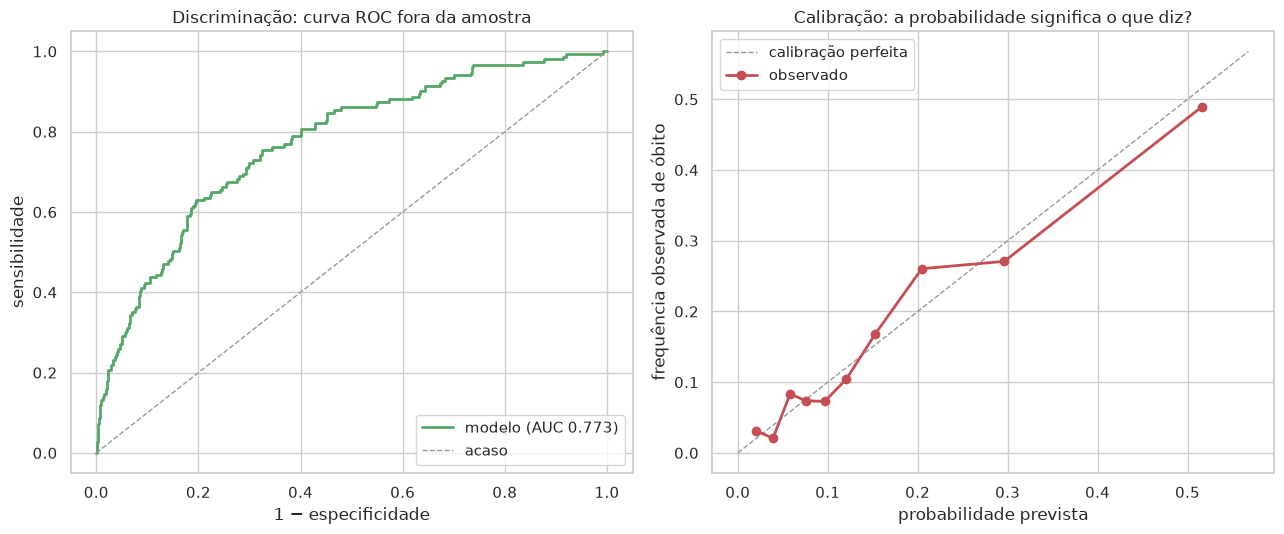

slope de calibração:     0.940  (ideal 1,0)
intercepto de calibração: -0.089  (ideal 0,0)


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

fpr, tpr, _ = roc_curve(y_modelo, risco_cv)
ax1.plot(
    fpr,
    tpr,
    color="#55a868",
    linewidth=2,
    label=f"modelo (AUC {roc_auc_score(y_modelo, risco_cv):.3f})",
)
ax1.plot([0, 1], [0, 1], "--", color="#999", linewidth=1, label="acaso")
ax1.set_xlabel("1 − especificidade")
ax1.set_ylabel("sensibilidade")
ax1.set_title("Discriminação: curva ROC fora da amostra")
ax1.legend(loc="lower right")

fracao, media_prevista = calibration_curve(y_modelo, risco_cv, n_bins=10, strategy="quantile")
ax2.plot(
    [0, max(media_prevista) * 1.1],
    [0, max(media_prevista) * 1.1],
    "--",
    color="#999",
    linewidth=1,
    label="calibração perfeita",
)
ax2.plot(media_prevista, fracao, marker="o", color="#c44e52", linewidth=2, label="observado")
ax2.set_xlabel("probabilidade prevista")
ax2.set_ylabel("frequência observada de óbito")
ax2.set_title("Calibração: a probabilidade significa o que diz?")
ax2.legend(loc="upper left")
plt.tight_layout()
plt.show()

# slope e intercepto de calibracao: o teste formal do grafico da direita
logito_previsto = np.log(
    np.clip(risco_cv, 1e-6, 1 - 1e-6) / (1 - np.clip(risco_cv, 1e-6, 1 - 1e-6))
)
calibracao = sm.Logit(y_modelo, sm.add_constant(logito_previsto)).fit(disp=0)
print(f"slope de calibração:     {calibracao.params.iloc[1]:.3f}  (ideal 1,0)")
print(f"intercepto de calibração: {calibracao.params.iloc[0]:+.3f}  (ideal 0,0)")

> **Como ler.** No painel da direita, a linha vermelha deve seguir a tracejada. Acima dela, o modelo **subestima** o risco; abaixo, **superestima**.
>
> O slope resume a inclinação dessa curva. Menor que 1 indica previsões esparramadas demais, com riscos altos otimistas demais e baixos pessimistas demais, que é o sinal clássico de sobreajuste. O intercepto indica desvio sistemático: positivo, o modelo subestima todo mundo.

## 5 O que o modelo mudaria na prática

Discriminação e calibração são propriedades do modelo. A pergunta clínica é outra: **usar este modelo levaria a decisões melhores do que não usar?**

A resposta depende do limiar de risco a partir do qual se decide intensificar vigilância, e esse limiar é uma escolha do serviço. A tabela abaixo mostra o que aconteceria em cada faixa.

In [7]:
estratos = pd.qcut(
    risco_cv,
    [0, 0.5, 0.8, 0.95, 1.0],
    labels=["50% de menor risco", "percentil 50 a 80", "percentil 80 a 95", "5% de maior risco"],
)
resumo = pd.DataFrame(
    {"estrato": estratos, "obito": y_modelo.to_numpy(), "risco_previsto": risco_cv}
)
tabela = resumo.groupby("estrato", observed=True).agg(
    internacoes=("obito", "size"),
    obitos=("obito", "sum"),
    mortalidade_pct=("obito", lambda s: round(s.mean() * 100, 1)),
    risco_medio_pct=("risco_previsto", lambda s: round(s.mean() * 100, 1)),
)
tabela["proporcao_dos_obitos_pct"] = (tabela.obitos / tabela.obitos.sum() * 100).round(1)
tabela

,internacoes,obitos,mortalidade_pct,risco_medio_pct,proporcao_dos_obitos_pct
estrato,,,,,
50% de menor risco,479,27,5.6,5.8,17.9
percentil 50 a 80,287,51,17.8,15.9,33.8
percentil 80 a 95,144,43,29.9,33.3,28.5
5% de maior risco,48,30,62.5,62.4,19.9


> **Como ler.** A coluna de mortalidade mostra se o modelo de fato separa os estratos. A última coluna responde à pergunta operacional: **que fatia de todos os óbitos está concentrada em cada faixa?**
>
> É esse número que decide viabilidade. Se os 20% de maior risco concentram metade dos óbitos, vigiar esse quinto captura metade dos casos com um quinto do esforço. Se concentram 25%, o modelo não está ajudando a priorizar nada, porque 25% é o que se obteria sorteando ao acaso.

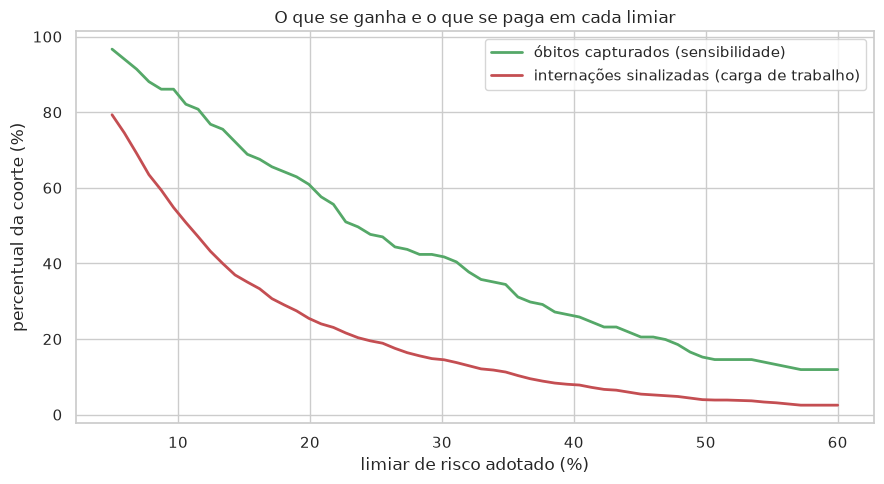

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
limiares = np.linspace(0.05, 0.60, 60)
sensibilidade = [(risco_cv[y_modelo == 1] >= t).mean() for t in limiares]
alarmes = [(risco_cv >= t).mean() for t in limiares]

ax.plot(
    limiares * 100,
    np.array(sensibilidade) * 100,
    color="#55a868",
    linewidth=2,
    label="óbitos capturados (sensibilidade)",
)
ax.plot(
    limiares * 100,
    np.array(alarmes) * 100,
    color="#c44e52",
    linewidth=2,
    label="internações sinalizadas (carga de trabalho)",
)
ax.set_xlabel("limiar de risco adotado (%)")
ax.set_ylabel("percentual da coorte (%)")
ax.set_title("O que se ganha e o que se paga em cada limiar")
ax.legend()
plt.tight_layout()
plt.show()

> **Como ler.** A distância vertical entre as curvas é o valor do modelo. Se em determinado limiar ele sinaliza 20% das internações e captura 55% dos óbitos, essa diferença de 35 pontos é o ganho sobre sinalizar ao acaso.
>
> Onde as duas curvas se encostam, o modelo não está discriminando naquela faixa, e adotar aquele limiar equivale a sortear. O gráfico não escolhe o limiar: ele mostra o custo de cada escolha para que o serviço decida com o próprio contexto de leitos e equipe.

## 6 A logística é mesmo a escolha certa?

A afirmação de que a logística basta precisa ser testada, não assumida. Três alternativas entram como comparação.

**Logística penalizada** encolhe coeficientes em direção a zero, o que ajuda quando há colinearidade. Serve para checar se a exclusão da creatinina foi acerto ou perda.

**Gradient boosting** captura não linearidade e interação automaticamente. Ele é o teto: se não superar a logística por margem relevante, isso é evidência de que não há estrutura complexa sendo desperdiçada, e o **resultado negativo fortalece o modelo simples**.

**Árvore de decisão** tem interesse específico aqui, porque o registro ADHERE, que ancora todo o projeto desde a Entrega 1, é exatamente uma árvore de classificação. Comparar formatos permite confrontar com o precedente.

In [9]:
alternativas = {
    "logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "logística penalizada (L2 forte)": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000, C=0.1)
    ),
    "gradient boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.05, random_state=SEED
    ),
    "árvore (formato ADHERE)": DecisionTreeClassifier(
        max_depth=3, min_samples_leaf=40, random_state=SEED
    ),
}

comparacao = []
for nome, estimador in alternativas.items():
    auc = cross_val_score(estimador, X_modelo, y_modelo, cv=cv, scoring="roc_auc")
    previsto = cross_val_predict(
        estimador,
        X_modelo,
        y_modelo,
        cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=SEED),
        method="predict_proba",
    )[:, 1]
    comparacao.append(
        {
            "modelo": nome,
            "AUC": round(auc.mean(), 3),
            "desvio": round(auc.std(), 3),
            "Brier": round(brier_score_loss(y_modelo, previsto), 4),
        }
    )
pd.DataFrame(comparacao)

,modelo,AUC,desvio,Brier
0,logística,0.776,0.043,0.1121
1,logística penalizada (L2 forte),0.776,0.043,0.1121
2,gradient boosting,0.744,0.044,0.1157
3,árvore (formato ADHERE),0.654,0.055,0.1254


> **Como ler.** A comparação não é uma competição a ser vencida pelo maior número. A pergunta é se algum método justifica abrir mão da interpretabilidade.
>
> Se o boosting superar a logística por menos de dois ou três pontos de AUC, a resposta é não: o custo de não conseguir explicar uma previsão ao clínico não se paga. Se superar por muito mais, isso indicaria não linearidade relevante, e o caminho seria investigar **qual** relação é não linear e representá-la na logística com termos apropriados, não trocar de família de modelo.
>
> O Brier merece atenção especial na árvore. Árvores rasas produzem poucas probabilidades distintas, uma por folha, e isso costuma piorar a calibração mesmo quando a discriminação parece boa.

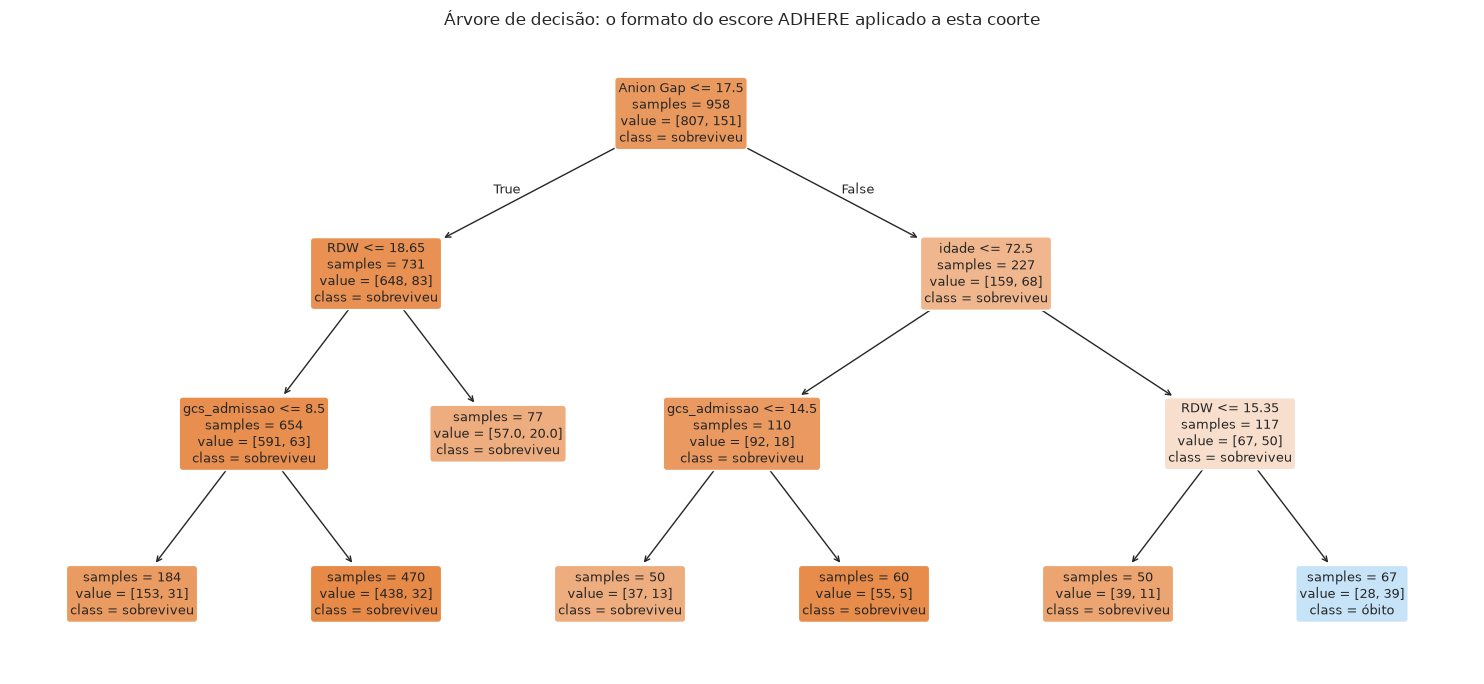

In [10]:
arvore = DecisionTreeClassifier(max_depth=3, min_samples_leaf=40, random_state=SEED)
arvore.fit(X_modelo, y_modelo)

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(
    arvore,
    feature_names=PREDITORES,
    class_names=["sobreviveu", "óbito"],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,
    ax=ax,
)
ax.set_title("Árvore de decisão: o formato do escore ADHERE aplicado a esta coorte")
plt.tight_layout()
plt.show()

> **Como ler.** A árvore é apresentada pelo que ela revela, não como modelo a adotar.
>
> O interesse está em **qual variável ela escolhe no primeiro corte** e em que valor. No ADHERE, o primeiro nó foi a ureia em 43 mg/dL. Se esta árvore escolher a mesma variável em valor próximo, é uma reprodução independente do precedente, com peso maior que qualquer teste de significância. Se escolher outra, o motivo precisa ser entendido, e a diferença mais provável é de população: o ADHERE cobre internações por insuficiência cardíaca em geral, enquanto esta coorte é restrita a quem passou por UTI.
>
> Árvores desta profundidade são instáveis: pequenas mudanças nos dados alteram os cortes. Ela serve para inspeção estrutural, não para predição.

## 7 O que falta antes de qualquer uso

Este notebook produz um modelo, não um instrumento clínico. A distância entre as duas coisas é a Entrega 3, e alguns itens ficam mesmo além dela.

**Validação externa.** Tudo aqui vem de um único centro e de uma amostra de 1.000 internações do MIMIC-IV. Um modelo que funciona nesta coorte pode falhar em outra população, com outra prevalência e outra rotina de solicitação de exames. Sem validação externa, não há uso clínico defensável.

**Validação temporal.** A amostra é aleatória, não cronológica. Prática clínica muda, e um modelo ajustado em dados antigos degrada com o tempo. Uma partição por período mostraria isso.

**Cobertura.** O modelo exige seis variáveis completas, disponíveis em 95,8% das internações. Os 4,2% restantes ficam sem previsão, e é preciso decidir o que fazer com eles antes de qualquer implantação.

**Seleção pela solicitação.** A Entrega 2 mostrou que a ausência de exame carrega informação clínica. Restringir a casos completos pode enviesar na direção dos pacientes de quem mais se pediu exame.

**Confundimento residual.** O ajuste cobre idade e Glasgow. Comorbidade, fração de ejeção, medicação em uso e tempo de doença não estão no corte.

**Impacto não medido.** Mesmo um modelo bem calibrado e validado pode não melhorar desfecho nenhum. Saber quem tem risco alto só ajuda se existir conduta que mude esse risco, e isso é pergunta de estudo prospectivo, não de análise retrospectiva.

> **O modelo prevê risco, não destino.** Ele estima com que frequência pacientes de um determinado perfil morreram nesta coorte. Não diz o que vai acontecer com a pessoa à sua frente, e não diz o que fazer a respeito.